<a href="https://colab.research.google.com/github/chris1982-arch/Lab2_Deep-Learning/blob/main/task1_vanilla_gan/task1_vanilla_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — Vanilla GAN (Paper Formulation)

This notebook implements a vanilla Generative Adversarial Network following Goodfellow et al. (2014) **as described in the original paper**: the Discriminator outputs a probability (via `sigmoid`) and training uses **Binary Cross-Entropy loss**.

**Reference:** Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)

**Run on Colab:** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chris1982-arch/Lab2_Deep-Learning/blob/main/task1_vanilla_gan/task1_vanilla_gan.ipynb)

---

## Theory

A GAN is a two-player minimax game between:
- **Generator** $G$: maps noise $z \sim p_z$ to fake samples $G(z)$
- **Discriminator** $D$: outputs the probability that a sample is real

The value function is:

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

At the global optimum, $p_g = p_{data}$ and $D(x) = 1/2$ everywhere (Theorem 1 of the paper).

**Non-saturating trick (Section 3):** instead of minimizing $\log(1 - D(G(z)))$, we train $G$ to *maximize* $\log D(G(z))$ — same fixed point, much stronger gradients early in training.

### Loss function choice for Task 1

Following the paper literally, the Discriminator outputs a probability in [0, 1] through a `sigmoid` activation, and the loss is computed using standard **Binary Cross-Entropy**:

$$L_D = -\mathbb{E}_{x \sim p_{data}}[\log D(x)] - \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$
$$L_G = -\mathbb{E}_{z \sim p_z}[\log D(G(z))]$$

In Task 2 we will replace this with the **logistic loss** (BCE-with-logits, as used in Brandon Amos's blog) and compare results.

In [1]:
!pip install wandb -q

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tqdm
import wandb

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Hyperparameters

In [2]:
mb_size = 128
Z_dim   = 100
X_dim   = 784       # 28 x 28 flattened
lr      = 2e-4
beta1   = 0.5
epochs  = 100

## Data

MNIST images are normalized to $[-1, 1]$ to match the `Tanh` output of the generator.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='./MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True, num_workers=2, drop_last=True)

print(f"Training set size: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.66MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Training set size: 60000
Batches per epoch: 468


## Generator

4-layer MLP: `z(100) → 256 → 512 → 1024 → x(784)`.
`LeakyReLU(0.2)` activations, `Tanh` output.

In [4]:
def xavier_init(m):
    """Xavier normal init — mentioned in the original tutorial code."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


class Generator(nn.Module):
    def __init__(self, z_dim=Z_dim, x_dim=X_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, x_dim),
            nn.Tanh()                          # output in [-1, 1]
        )
        self.apply(xavier_init)

    def forward(self, z):
        return self.net(z)

## Discriminator — with Sigmoid output (paper formulation)

4-layer MLP ending in **`Sigmoid`** so the output is a probability in [0, 1].

In Task 2 we will remove this sigmoid and use `BCEWithLogitsLoss` instead (the logistic loss formulation).

In [5]:
class Discriminator(nn.Module):
    """
    D: x -> probability that x is real (in [0, 1] via sigmoid).
    """
    def __init__(self, x_dim=X_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()                       # output in [0, 1] — paper formulation
        )
        self.apply(xavier_init)

    def forward(self, x):
        return self.net(x)

## Training loop

Following **Algorithm 1** of the paper with `k=1`: alternate one D step with one G step.

**Loss used here:** `nn.BCELoss()` — standard Binary Cross-Entropy applied to the sigmoid outputs of D. This is the classical formulation from the paper.

Key implementation details:
- **D step:** `BCE(D(x), 1) + BCE(D(G(z)), 0)`
- **G step (non-saturating):** `BCE(D(G(z)), 1)` — trains G to maximize `log D(G(z))`
- **Label smoothing** (real = 0.9 instead of 1.0) prevents D from becoming overconfident
- **`G_sample.detach()`** in D step cuts gradient flow to G when training D
- Outputs are clamped to `[eps, 1-eps]` to avoid `log(0)` numerical issues

In [6]:
EPS = 1e-7   # for numerical safety in BCE

def train_one_epoch(G, D, loss_fn, G_solver, D_solver, train_loader, epoch):
    G.train(); D.train()
    D_loss_real_total = D_loss_fake_total = G_loss_total = 0.0
    D_real_score = D_fake_score = 0.0

    pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch}")
    for X_real, _ in pbar:
        X_real = X_real.to(device)
        bsz = X_real.size(0)

        # Label smoothing: real=0.9, fake=0.0
        real_label = torch.full((bsz, 1), 0.9, device=device)
        fake_label = torch.zeros((bsz, 1), device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bsz, Z_dim, device=device)
        G_sample = G(z)
        D_real = D(X_real).clamp(EPS, 1 - EPS)
        D_fake = D(G_sample.detach()).clamp(EPS, 1 - EPS)     # cut gradient to G
        D_loss_real = loss_fn(D_real, real_label)
        D_loss_fake = loss_fn(D_fake, fake_label)
        D_loss = D_loss_real + D_loss_fake

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ---- Train Generator (non-saturating) ----
        z = torch.randn(bsz, Z_dim, device=device)
        G_sample = G(z)
        D_fake = D(G_sample).clamp(EPS, 1 - EPS)
        G_loss = loss_fn(D_fake, torch.ones((bsz, 1), device=device))

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # ---- Bookkeeping ----
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()
        G_loss_total      += G_loss.item()
        D_real_score      += D_real.mean().item()
        D_fake_score      += D_fake.mean().item()

        pbar.set_postfix(D_loss=f"{D_loss.item():.3f}",
                         G_loss=f"{G_loss.item():.3f}")

    n = len(train_loader)
    return {
        "D_loss_real": D_loss_real_total / n,
        "D_loss_fake": D_loss_fake_total / n,
        "D_loss":      (D_loss_real_total + D_loss_fake_total) / n,
        "G_loss":      G_loss_total / n,
        "D(x)":        D_real_score / n,              # should drift toward 0.5
        "D(G(z))":     D_fake_score / n,              # should drift toward 0.5
    }

## Sample visualization

In [7]:
def show_samples(G, epoch, n=16):
    """Generate and display a 4x4 grid of samples. Also saves to disk."""
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, Z_dim, device=device)
        samples = G(z).cpu().numpy()
    samples = (samples + 1) / 2  # [-1,1] -> [0,1] for display

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)
    for i, s in enumerate(samples):
        ax = plt.subplot(gs[i])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal')
        plt.imshow(s.reshape(28, 28), cmap='Greys_r')

    os.makedirs("results/samples", exist_ok=True)
    path = f"results/samples/epoch_{str(epoch).zfill(3)}.png"
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    return path

## Run training

Training 100 epochs on a Colab T4 GPU takes ~25-30 minutes.

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chrispalandz (chrispalandz-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 100%|██████████| 468/468 [00:17<00:00, 26.24it/s, D_loss=1.049, G_loss=0.836]


[epoch 000] D_loss=1.0640  G_loss=1.3534  D(x)=0.716  D(G(z))=0.292


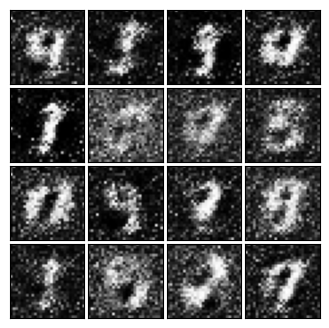

Epoch 1: 100%|██████████| 468/468 [00:19<00:00, 24.38it/s, D_loss=0.815, G_loss=2.923]


[epoch 001] D_loss=0.9213  G_loss=2.0131  D(x)=0.685  D(G(z))=0.176


Epoch 2: 100%|██████████| 468/468 [00:18<00:00, 25.65it/s, D_loss=0.816, G_loss=2.137]


[epoch 002] D_loss=0.9141  G_loss=2.0524  D(x)=0.683  D(G(z))=0.180


Epoch 3: 100%|██████████| 468/468 [00:18<00:00, 25.79it/s, D_loss=0.922, G_loss=1.615]


...

[epoch 008] D_loss=1.1142  G_loss=1.3906  D(x)=0.588  D(G(z))=0.298


Epoch 9: 100%|██████████| 468/468 [00:19<00:00, 23.92it/s, D_loss=1.229, G_loss=1.499]


[epoch 009] D_loss=1.1582  G_loss=1.2826  D(x)=0.567  D(G(z))=0.322


Epoch 10: 100%|██████████| 468/468 [00:17<00:00, 26.04it/s, D_loss=1.218, G_loss=1.280]


[epoch 010] D_loss=1.1716  G_loss=1.2508  D(x)=0.559  D(G(z))=0.328


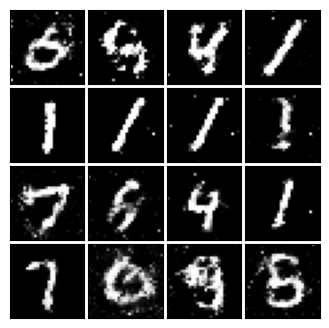

Epoch 11: 100%|██████████| 468/468 [00:18<00:00, 25.38it/s, D_loss=1.238, G_loss=1.025]


[epoch 011] D_loss=1.1886  G_loss=1.2090  D(x)=0.551  D(G(z))=0.337


Epoch 12: 100%|██████████| 468/468 [00:18<00:00, 25.22it/s, D_loss=1.212, G_loss=1.158]


[epoch 012] D_loss=1.2029  G_loss=1.1798  D(x)=0.544  D(G(z))=0.345


Epoch 13: 100%|██████████| 468/468 [00:19<00:00, 23.94it/s, D_loss=1.189, G_loss=1.124]


...

[epoch 018] D_loss=1.2510  G_loss=1.0774  D(x)=0.519  D(G(z))=0.370


Epoch 19: 100%|██████████| 468/468 [00:18<00:00, 25.40it/s, D_loss=1.290, G_loss=1.150]


[epoch 019] D_loss=1.2527  G_loss=1.0737  D(x)=0.519  D(G(z))=0.371


Epoch 20: 100%|██████████| 468/468 [00:18<00:00, 25.82it/s, D_loss=1.240, G_loss=1.238]


[epoch 020] D_loss=1.2579  G_loss=1.0672  D(x)=0.515  D(G(z))=0.373


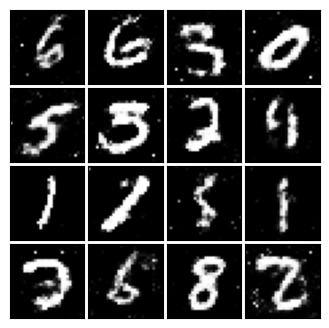

Epoch 21: 100%|██████████| 468/468 [00:19<00:00, 23.88it/s, D_loss=1.267, G_loss=1.011]


[epoch 021] D_loss=1.2613  G_loss=1.0576  D(x)=0.514  D(G(z))=0.376


Epoch 22: 100%|██████████| 468/468 [00:19<00:00, 24.28it/s, D_loss=1.289, G_loss=1.084]


[epoch 022] D_loss=1.2622  G_loss=1.0520  D(x)=0.513  D(G(z))=0.377


Epoch 23: 100%|██████████| 468/468 [00:18<00:00, 24.97it/s, D_loss=1.318, G_loss=0.878]


...

[epoch 028] D_loss=1.2696  G_loss=1.0369  D(x)=0.509  D(G(z))=0.381


Epoch 29: 100%|██████████| 468/468 [00:19<00:00, 23.69it/s, D_loss=1.273, G_loss=1.191]


[epoch 029] D_loss=1.2748  G_loss=1.0319  D(x)=0.506  D(G(z))=0.382


Epoch 30: 100%|██████████| 468/468 [00:19<00:00, 24.19it/s, D_loss=1.267, G_loss=1.165]


[epoch 030] D_loss=1.2723  G_loss=1.0289  D(x)=0.507  D(G(z))=0.383


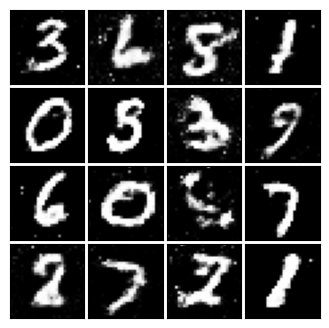

Epoch 31: 100%|██████████| 468/468 [00:19<00:00, 24.51it/s, D_loss=1.252, G_loss=0.944]


[epoch 031] D_loss=1.2726  G_loss=1.0301  D(x)=0.507  D(G(z))=0.383


Epoch 32: 100%|██████████| 468/468 [00:19<00:00, 24.18it/s, D_loss=1.269, G_loss=1.091]


[epoch 032] D_loss=1.2738  G_loss=1.0215  D(x)=0.507  D(G(z))=0.386


Epoch 33: 100%|██████████| 468/468 [00:20<00:00, 22.73it/s, D_loss=1.275, G_loss=0.955]


...

[epoch 038] D_loss=1.2791  G_loss=1.0149  D(x)=0.504  D(G(z))=0.387


Epoch 39: 100%|██████████| 468/468 [00:19<00:00, 24.53it/s, D_loss=1.284, G_loss=0.961]


[epoch 039] D_loss=1.2776  G_loss=1.0143  D(x)=0.504  D(G(z))=0.387


Epoch 40: 100%|██████████| 468/468 [00:19<00:00, 23.56it/s, D_loss=1.271, G_loss=1.189]


[epoch 040] D_loss=1.2774  G_loss=1.0178  D(x)=0.504  D(G(z))=0.386


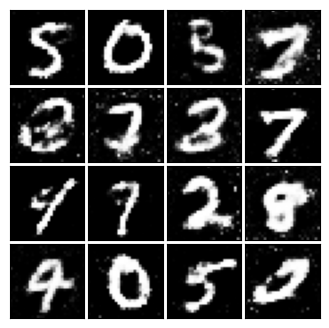

Epoch 41: 100%|██████████| 468/468 [00:20<00:00, 23.35it/s, D_loss=1.222, G_loss=0.930]


[epoch 041] D_loss=1.2796  G_loss=1.0124  D(x)=0.503  D(G(z))=0.388


Epoch 42: 100%|██████████| 468/468 [00:19<00:00, 23.74it/s, D_loss=1.244, G_loss=1.097]


[epoch 042] D_loss=1.2794  G_loss=1.0122  D(x)=0.503  D(G(z))=0.388


Epoch 43: 100%|██████████| 468/468 [00:19<00:00, 23.92it/s, D_loss=1.258, G_loss=1.021]


...

[epoch 048] D_loss=1.2793  G_loss=1.0080  D(x)=0.503  D(G(z))=0.389


Epoch 49: 100%|██████████| 468/468 [00:19<00:00, 23.83it/s, D_loss=1.224, G_loss=0.868]


[epoch 049] D_loss=1.2807  G_loss=1.0082  D(x)=0.502  D(G(z))=0.389


Epoch 50: 100%|██████████| 468/468 [00:19<00:00, 23.85it/s, D_loss=1.304, G_loss=0.966]


[epoch 050] D_loss=1.2807  G_loss=1.0041  D(x)=0.502  D(G(z))=0.390


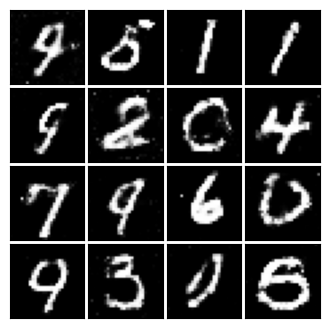

Epoch 51: 100%|██████████| 468/468 [00:20<00:00, 22.75it/s, D_loss=1.198, G_loss=1.150]


[epoch 051] D_loss=1.2811  G_loss=1.0061  D(x)=0.502  D(G(z))=0.390


Epoch 52: 100%|██████████| 468/468 [00:21<00:00, 22.17it/s, D_loss=1.301, G_loss=0.948]


[epoch 052] D_loss=1.2821  G_loss=1.0041  D(x)=0.501  D(G(z))=0.390


Epoch 53: 100%|██████████| 468/468 [00:19<00:00, 23.66it/s, D_loss=1.316, G_loss=1.059]


...

[epoch 058] D_loss=1.2794  G_loss=1.0031  D(x)=0.503  D(G(z))=0.390


Epoch 59: 100%|██████████| 468/468 [00:21<00:00, 22.24it/s, D_loss=1.294, G_loss=0.999]


[epoch 059] D_loss=1.2802  G_loss=1.0078  D(x)=0.502  D(G(z))=0.388


Epoch 60: 100%|██████████| 468/468 [00:20<00:00, 23.31it/s, D_loss=1.321, G_loss=1.024]


[epoch 060] D_loss=1.2804  G_loss=1.0080  D(x)=0.502  D(G(z))=0.388


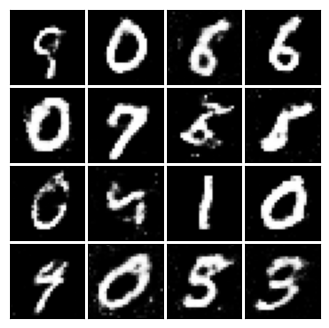

Epoch 61: 100%|██████████| 468/468 [00:19<00:00, 23.66it/s, D_loss=1.313, G_loss=1.124]


[epoch 061] D_loss=1.2804  G_loss=1.0062  D(x)=0.502  D(G(z))=0.389


Epoch 62: 100%|██████████| 468/468 [00:19<00:00, 23.68it/s, D_loss=1.275, G_loss=1.040]


[epoch 062] D_loss=1.2809  G_loss=1.0022  D(x)=0.502  D(G(z))=0.391


Epoch 63: 100%|██████████| 468/468 [00:20<00:00, 22.40it/s, D_loss=1.269, G_loss=0.991]


...

[epoch 068] D_loss=1.2794  G_loss=1.0015  D(x)=0.502  D(G(z))=0.391


Epoch 69: 100%|██████████| 468/468 [00:19<00:00, 24.16it/s, D_loss=1.258, G_loss=0.946]


[epoch 069] D_loss=1.2794  G_loss=1.0067  D(x)=0.502  D(G(z))=0.390


Epoch 70: 100%|██████████| 468/468 [00:19<00:00, 23.61it/s, D_loss=1.314, G_loss=0.947]


[epoch 070] D_loss=1.2786  G_loss=1.0056  D(x)=0.503  D(G(z))=0.390


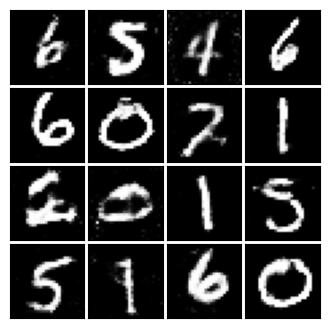

Epoch 71: 100%|██████████| 468/468 [00:21<00:00, 22.19it/s, D_loss=1.252, G_loss=1.065]


[epoch 071] D_loss=1.2797  G_loss=1.0037  D(x)=0.502  D(G(z))=0.390


Epoch 72: 100%|██████████| 468/468 [00:20<00:00, 23.36it/s, D_loss=1.303, G_loss=1.000]


[epoch 072] D_loss=1.2788  G_loss=1.0044  D(x)=0.502  D(G(z))=0.390


Epoch 73: 100%|██████████| 468/468 [00:19<00:00, 23.50it/s, D_loss=1.319, G_loss=1.190]


...

[epoch 078] D_loss=1.2761  G_loss=1.0118  D(x)=0.503  D(G(z))=0.388


Epoch 79: 100%|██████████| 468/468 [00:20<00:00, 22.99it/s, D_loss=1.247, G_loss=1.002]


[epoch 079] D_loss=1.2753  G_loss=1.0109  D(x)=0.504  D(G(z))=0.388


Epoch 80: 100%|██████████| 468/468 [00:19<00:00, 23.45it/s, D_loss=1.348, G_loss=1.078]


[epoch 080] D_loss=1.2781  G_loss=1.0067  D(x)=0.503  D(G(z))=0.390


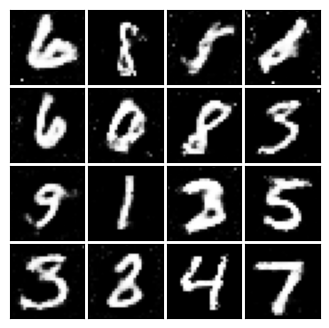

Epoch 81: 100%|██████████| 468/468 [00:19<00:00, 23.53it/s, D_loss=1.301, G_loss=1.115]


[epoch 081] D_loss=1.2770  G_loss=1.0128  D(x)=0.503  D(G(z))=0.388


Epoch 82: 100%|██████████| 468/468 [00:20<00:00, 23.08it/s, D_loss=1.271, G_loss=1.250]


[epoch 082] D_loss=1.2784  G_loss=1.0087  D(x)=0.503  D(G(z))=0.389


Epoch 83: 100%|██████████| 468/468 [00:20<00:00, 22.34it/s, D_loss=1.295, G_loss=1.158]


...

[epoch 088] D_loss=1.2773  G_loss=1.0076  D(x)=0.503  D(G(z))=0.390


Epoch 89: 100%|██████████| 468/468 [00:20<00:00, 23.23it/s, D_loss=1.239, G_loss=0.961]


[epoch 089] D_loss=1.2767  G_loss=1.0075  D(x)=0.503  D(G(z))=0.390


Epoch 90: 100%|██████████| 468/468 [00:20<00:00, 23.11it/s, D_loss=1.282, G_loss=1.097]


[epoch 090] D_loss=1.2738  G_loss=1.0073  D(x)=0.505  D(G(z))=0.390


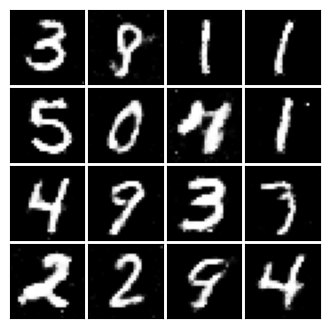

Epoch 91: 100%|██████████| 468/468 [00:21<00:00, 21.92it/s, D_loss=1.334, G_loss=0.863]


[epoch 091] D_loss=1.2771  G_loss=1.0065  D(x)=0.503  D(G(z))=0.390


Epoch 92: 100%|██████████| 468/468 [00:21<00:00, 21.64it/s, D_loss=1.342, G_loss=1.291]


[epoch 092] D_loss=1.2734  G_loss=1.0152  D(x)=0.505  D(G(z))=0.388


Epoch 93: 100%|██████████| 468/468 [00:20<00:00, 23.01it/s, D_loss=1.311, G_loss=1.024]


...

[epoch 097] D_loss=1.2762  G_loss=1.0115  D(x)=0.503  D(G(z))=0.388


Epoch 98: 100%|██████████| 468/468 [00:20<00:00, 22.53it/s, D_loss=1.286, G_loss=0.876]


[epoch 098] D_loss=1.2754  G_loss=1.0088  D(x)=0.504  D(G(z))=0.389


Epoch 99: 100%|██████████| 468/468 [00:21<00:00, 21.89it/s, D_loss=1.306, G_loss=0.918]


[epoch 099] D_loss=1.2748  G_loss=1.0078  D(x)=0.504  D(G(z))=0.390


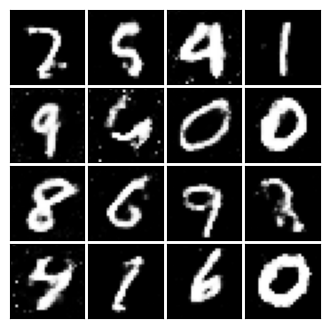

D(G(z)),▁▃▄▅▆▆▇▇▇███████████████████████████████
D(x),████▇▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss,▁▂▃▄▆▇▇▇▇███████████████████████████████
D_loss_fake,▁▁▃▆▆▇██████████████████████████████████
D_loss_real,▁▄▄▄▅▇▇▇▇███████████████████████████████
G_loss,███▇▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
D(G(z)),0.38954
D(x),0.50418
D_loss,1.27479
D_loss_fake,0.53476


In [8]:
USE_WANDB = True

G = Generator().to(device)
D = Discriminator().to(device)

G_solver = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
D_solver = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
loss_fn = nn.BCELoss()              # classical BCE (paper formulation)

if USE_WANDB:
    wandb.init(project="vanilla-gan-mnist", name="task1_paper_bce",
               config={
        "batch_size": mb_size, "Z_dim": Z_dim, "X_dim": X_dim,
        "lr": lr, "beta1": beta1, "epochs": epochs,
        "loss": "BCELoss (sigmoid + BCE, paper formulation)",
        "task": "Task 1 — Vanilla GAN",
    })

history = {"D_loss": [], "G_loss": [], "D(x)": [], "D(G(z))": []}
best_g_loss = float('inf')
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(epochs):
    metrics = train_one_epoch(G, D, loss_fn, G_solver, D_solver, train_loader, epoch)
    for k in history:
        history[k].append(metrics[k])
    print(f"[epoch {epoch:03d}] "
          f"D_loss={metrics['D_loss']:.4f}  "
          f"G_loss={metrics['G_loss']:.4f}  "
          f"D(x)={metrics['D(x)']:.3f}  "
          f"D(G(z))={metrics['D(G(z))']:.3f}")

    if epoch % 10 == 0 or epoch == epochs - 1:
        sample_path = show_samples(G, epoch)
        if USE_WANDB:
            wandb.log({**metrics, "samples": wandb.Image(sample_path), "epoch": epoch})
    elif USE_WANDB:
        wandb.log({**metrics, "epoch": epoch})

    if metrics["G_loss"] < best_g_loss:
        best_g_loss = metrics["G_loss"]
        torch.save(G.state_dict(), "checkpoints/G_best.pth")
        torch.save(D.state_dict(), "checkpoints/D_best.pth")

if USE_WANDB:
    wandb.finish()

## Training curves

- **Left:** D loss and G loss over time. Expect oscillation around a steady value.
- **Right:** `D(x)` and `D(G(z))` drift toward **0.5** (Nash equilibrium, Theorem 1 of the paper).

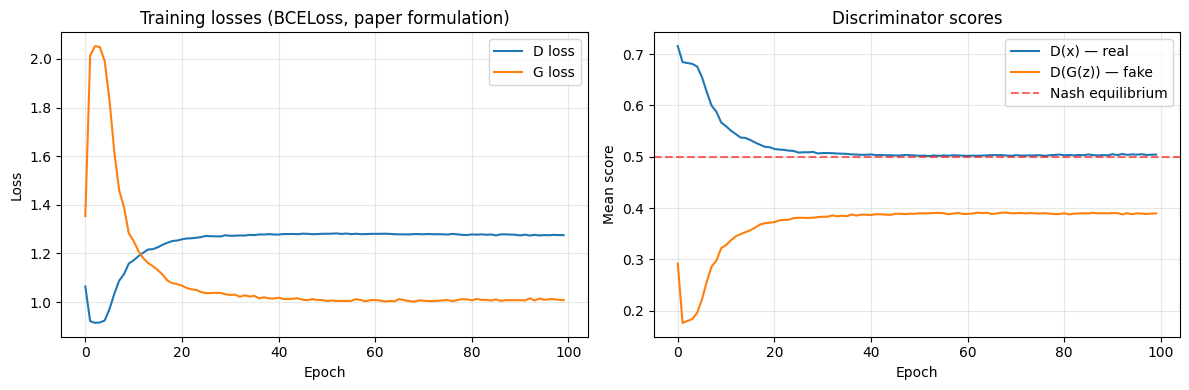

In [9]:
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["D_loss"], label="D loss")
axes[0].plot(history["G_loss"], label="G loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Training losses (BCELoss, paper formulation)")
axes[0].grid(alpha=0.3)

axes[1].plot(history["D(x)"], label="D(x) — real")
axes[1].plot(history["D(G(z))"], label="D(G(z)) — fake")
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label="Nash equilibrium")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean score")
axes[1].legend()
axes[1].set_title("Discriminator scores")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/training_curves.png", bbox_inches='tight', dpi=120)
plt.show()

## Final samples

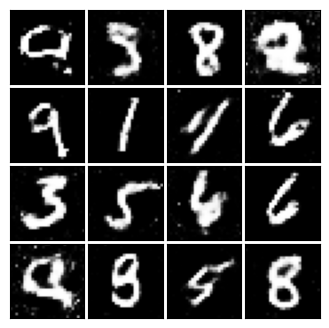

Final grid saved to: results/samples/epoch_final.png


In [10]:
G.load_state_dict(torch.load("checkpoints/G_best.pth"))
final_path = show_samples(G, "final", n=16)
print(f"Final grid saved to: {final_path}")

## Conclusions — Task 1

This notebook implements the **classical paper formulation** of the vanilla GAN:
- Discriminator outputs a probability through `Sigmoid`
- Loss computed via standard `nn.BCELoss()`
- Non-saturating generator objective (maximize `log D(G(z))`)

**Observations:**
- D(x) and D(G(z)) converge toward 0.5, confirming the Nash equilibrium predicted by Theorem 1
- Generated samples become recognizable MNIST digits around epoch 20-30
- Losses oscillate rather than decrease monotonically — characteristic of adversarial training

**Known issue with this formulation:** when D becomes very confident (outputs near 0 or 1), the sigmoid saturates and gradients vanish. The `.clamp(EPS, 1-EPS)` trick prevents `log(0)` but does not fix saturation — this is why, in Task 2, we will switch to the **logistic loss** (BCE-with-logits), as recommended by Brandon Amos in his image completion blog post.

**Next (Task 2):** replace `Sigmoid + BCELoss` with `logits + BCEWithLogitsLoss`, observe the differences at 5, 10, and 50 epochs.